In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split, WeightedRandomSampler
import torchvision.transforms as transforms
from torchvision.models.video import r3d_18, R3D_18_Weights
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

c:\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
GPU: NVIDIA GeForce RTX 2070 with Max-Q Design


In [2]:
class RouletteVideoDataset(Dataset):
    """
    Dataset for roulette videos.
    Loads video clips and returns tensor of shape (C, T, H, W)
    """
    
    def __init__(self, csv_path, dataset_root, num_frames=16, frame_size=112, transform=None, augment=False):
        """
        Args:
            csv_path: Path to CSV with columns ['input_path', 'label']
            dataset_root: Root directory of the dataset
            num_frames: Number of frames to sample from each video
            frame_size: Size to resize frames to (frame_size x frame_size)
            transform: Optional transforms to apply
            augment: If True, apply data augmentation
        """
        self.df = pd.read_csv(csv_path)
        self.df = self.df.dropna(subset=['label']).reset_index(drop=True)
        self.dataset_root = Path(dataset_root)
        self.num_frames = num_frames
        self.frame_size = frame_size
        self.transform = transform
        self.augment = augment
        
        # Kinetics-400 normalization
        self.mean = torch.tensor([0.43216, 0.394666, 0.37645])
        self.std = torch.tensor([0.22803, 0.22145, 0.216989])
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        # Get video path and label
        video_rel_path = self.df.iloc[idx]['input_path']
        label = int(self.df.iloc[idx]['label'])
        video_path = self.dataset_root / video_rel_path
        
        frames = self._load_video(video_path)
        
        # Convert to tensor (C, T, H, W)
        if self.transform:
            frames = self.transform(frames)
        
        return frames, label
    
    def _load_video(self, video_path):
        """Load video and sample num_frames"""
        cap = cv2.VideoCapture(str(video_path))
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        
        # Determine starting frame
        if self.augment:
            # Random start between frame 0-7 (if video is long enough)
            max_start_frame = min(8, max(1, total_frames - self.num_frames))
            start_frame = np.random.randint(0, max_start_frame)
        else:
            start_frame = 0
        
        # Take frames from the starting point
        if total_frames < start_frame + self.num_frames:
            # If video has fewer frames, use what we have and repeat last frame
            available_frames = max(1, total_frames - start_frame)
            indices = list(range(start_frame, start_frame + available_frames))
            indices += [indices[-1]] * (self.num_frames - len(indices))
        else:
            indices = list(range(start_frame, start_frame + self.num_frames))
        
        frames = []
        for idx in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
            ret, frame = cap.read()
            if ret:
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                frame = cv2.resize(frame, (self.frame_size, self.frame_size))
                frame = frame.astype(np.float32) / 255.0
                frames.append(frame)
        
        cap.release()
        
        # (T, H, W, C)
        frames = np.stack(frames, axis=0)
        
        # Random horizontal flip augmentation
        if self.augment and np.random.random() > 0.5:
            frames = np.flip(frames, axis=2).copy()  # Flip width axis
        
        # Convert to (C, T, H, W) for PyTorch
        frames = torch.from_numpy(frames).permute(3, 0, 1, 2)
        
        # Apply Kinetics-400 normalization
        mean = self.mean.view(3, 1, 1, 1)
        std = self.std.view(3, 1, 1, 1)
        frames = (frames - mean) / std
        
        return frames

## 3. Model

In [3]:
class RoulettePredictor(nn.Module):
    
    def __init__(self, num_classes=37, freeze_backbone=True):
        """
        Args:
            num_classes: Number of roulette numbers
            freeze_backbone: If True, only train the final layer
        """
        super(RoulettePredictor, self).__init__()
        
        weights = R3D_18_Weights.KINETICS400_V1
        self.model = r3d_18(weights=weights)
        
        if freeze_backbone:
            for param in self.model.parameters():
                param.requires_grad = False
        
        in_features = self.model.fc.in_features
        self.model.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
        
    def forward(self, x):
        """
            x: (batch, C, T, H, W)
        """
        return self.model(x)
    
    def unfreeze_backbone(self):
        for param in self.model.parameters():
            param.requires_grad = True

model = RoulettePredictor(num_classes=37, freeze_backbone=True)
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Total parameters: 33,307,109
Trainable parameters: 140,837


In [4]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    correct_top5 = 0
    total = 0
    
    pbar = tqdm(dataloader, desc='Training')
    for videos, labels in pbar:
        videos, labels = videos.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(videos)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        # Statistics
        running_loss += loss.item() * videos.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        # Top-5 accuracy
        _, top5_pred = outputs.topk(5, 1, True, True)
        top5_pred = top5_pred.t()
        correct_top5 += top5_pred.eq(labels.view(1, -1).expand_as(top5_pred)).sum().item()
        
        # Update progress bar
        pbar.set_postfix({
            'loss': loss.item(), 
            'acc': 100 * correct / total,
            'top5': 100 * correct_top5 / total
        })
    
    epoch_loss = running_loss / total
    epoch_acc = 100 * correct / total
    epoch_top5_acc = 100 * correct_top5 / total
    return epoch_loss, epoch_acc, epoch_top5_acc

def test(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    correct_top5 = 0
    total = 0
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        pbar = tqdm(dataloader, desc='Testing')
        for videos, labels in pbar:
            videos, labels = videos.to(device), labels.to(device)
            
            outputs = model(videos)
            loss = criterion(outputs, labels)
            
            # Get probabilities
            probs = torch.softmax(outputs, dim=1)
            
            # Statistics
            running_loss += loss.item() * videos.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            # Top-5 accuracy
            _, top5_pred = outputs.topk(5, 1, True, True)
            top5_pred = top5_pred.t()
            correct_top5 += top5_pred.eq(labels.view(1, -1).expand_as(top5_pred)).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            
            # Update progress bar
            pbar.set_postfix({
                'loss': loss.item(), 
                'acc': 100 * correct / total,
                'top5': 100 * correct_top5 / total
            })
    
    epoch_loss = running_loss / total
    epoch_acc = 100 * correct / total
    epoch_top5_acc = 100 * correct_top5 / total
    return epoch_loss, epoch_acc, epoch_top5_acc, all_preds, all_labels, all_probs

## 5. Dataset

In [5]:
CONFIG = {
    'dataset_root': 'RouletteVision-Dataset',
    'csv_path': 'dataset_labels_combined.csv',
    'num_frames': 16,
    'frame_size': 112,
    'batch_size': 8,
    'num_workers': 0,
    'train_split': 0.85,  # Train/Test
    'val_split': 0.10,    # Train in to Train/Val
    'learning_rate': 1e-3,
    'num_epochs': 10,
    'save_path': 'roulette_model.pth'
}

dataset_aug = RouletteVideoDataset(
    csv_path=CONFIG['csv_path'],
    dataset_root=CONFIG['dataset_root'],
    num_frames=CONFIG['num_frames'],
    frame_size=CONFIG['frame_size'],
    augment=True
)

dataset_no_aug = RouletteVideoDataset(
    csv_path=CONFIG['csv_path'],
    dataset_root=CONFIG['dataset_root'],
    num_frames=CONFIG['num_frames'],
    frame_size=CONFIG['frame_size'],
    augment=False
)

total_size = len(dataset_aug)
train_val_size = int(CONFIG['train_split'] * total_size)
test_size = total_size - train_val_size

train_size = int((1 - CONFIG['val_split']) * train_val_size)
val_size = train_val_size - train_size

from torch.utils.data import Subset
indices = list(range(total_size))
train_indices = indices[:train_size]
val_indices = indices[train_size:train_val_size]
test_indices = indices[train_val_size:]

train_dataset = Subset(dataset_aug, train_indices)
val_dataset = Subset(dataset_no_aug, val_indices)
test_dataset = Subset(dataset_no_aug, test_indices)

# Create sampler for training to handle class imbalance
all_labels = [int(dataset_aug.df.iloc[i]['label']) for i in range(len(dataset_aug))]
train_labels = [all_labels[idx] for idx in train_indices]

# Count class occurrences in training set
class_counts = np.bincount(train_labels, minlength=37)
class_weights = 1.0 / (class_counts + 1e-6)
sample_weights = [class_weights[label] for label in train_labels]

train_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG['batch_size'],
    sampler=train_sampler,
    num_workers=CONFIG['num_workers'], 
    pin_memory=True, 
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=CONFIG['batch_size'], 
    shuffle=False, 
    num_workers=CONFIG['num_workers'],
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=CONFIG['batch_size'], 
    shuffle=False, 
    num_workers=CONFIG['num_workers'],
    pin_memory=True
)

print(f"Dataset loaded: {total_size} videos")
print(f"   Training: {train_size} videos ({train_size/total_size*100:.1f}%) - with augmentation")
print(f"   Validation: {val_size} videos ({val_size/total_size*100:.1f}%) - no augmentation")
print(f"   Test: {test_size} videos ({test_size/total_size*100:.1f}%) - held out, no augmentation")
print(f"\nAugmentation strategies (training only):")
print(f"   - Random start frame: 0-7")
print(f"   - Random horizontal flip: 50% chance")

Dataset loaded: 1703 videos
   Training: 1302 videos (76.5%) - with augmentation
   Validation: 145 videos (8.5%) - no augmentation
   Test: 256 videos (15.0%) - held out, no augmentation

Augmentation strategies (training only):
   - Random start frame: 0-7
   - Random horizontal flip: 50% chance


In [6]:
# Test data loading
print("Testing train_loader...")
print(f"Total batches in train_loader: {len(train_loader)}")
print(f"Batch size: {CONFIG['batch_size']}")

# Load first batch
print("\n" + "="*60)
print("Loading first batch...")
batch_videos, batch_labels = next(iter(train_loader))

print(f"\nSuccessfully loaded batch!")
print(f"Videos shape: {batch_videos.shape}")  # Should be (batch, C, T, H, W)
print(f"Labels shape: {batch_labels.shape}")  # Should be (batch,)
print(f"Videos dtype: {batch_videos.dtype}")
print(f"Labels dtype: {batch_labels.dtype}")
print(f"Videos range: [{batch_videos.min():.3f}, {batch_videos.max():.3f}]")
print(f"Labels: {batch_labels.tolist()}")

Testing train_loader...
Total batches in train_loader: 163
Batch size: 8

Loading first batch...

Successfully loaded batch!
Videos shape: torch.Size([8, 3, 16, 112, 112])
Labels shape: torch.Size([8])
Videos dtype: torch.float32
Labels dtype: torch.int64
Videos range: [-1.895, 2.801]
Labels: [33, 18, 7, 5, 12, 26, 21, 17]


Visualizing RAW and PREPROCESSED frames from 1 random video:
Video: ../RouletteVision-Dataset/Input-Output Videos/SET 1/S1_INPUT_258.mp4
Label: 32
Preprocessed shape: torch.Size([3, 16, 112, 112])
Raw frame shape: (1080, 1920, 3)


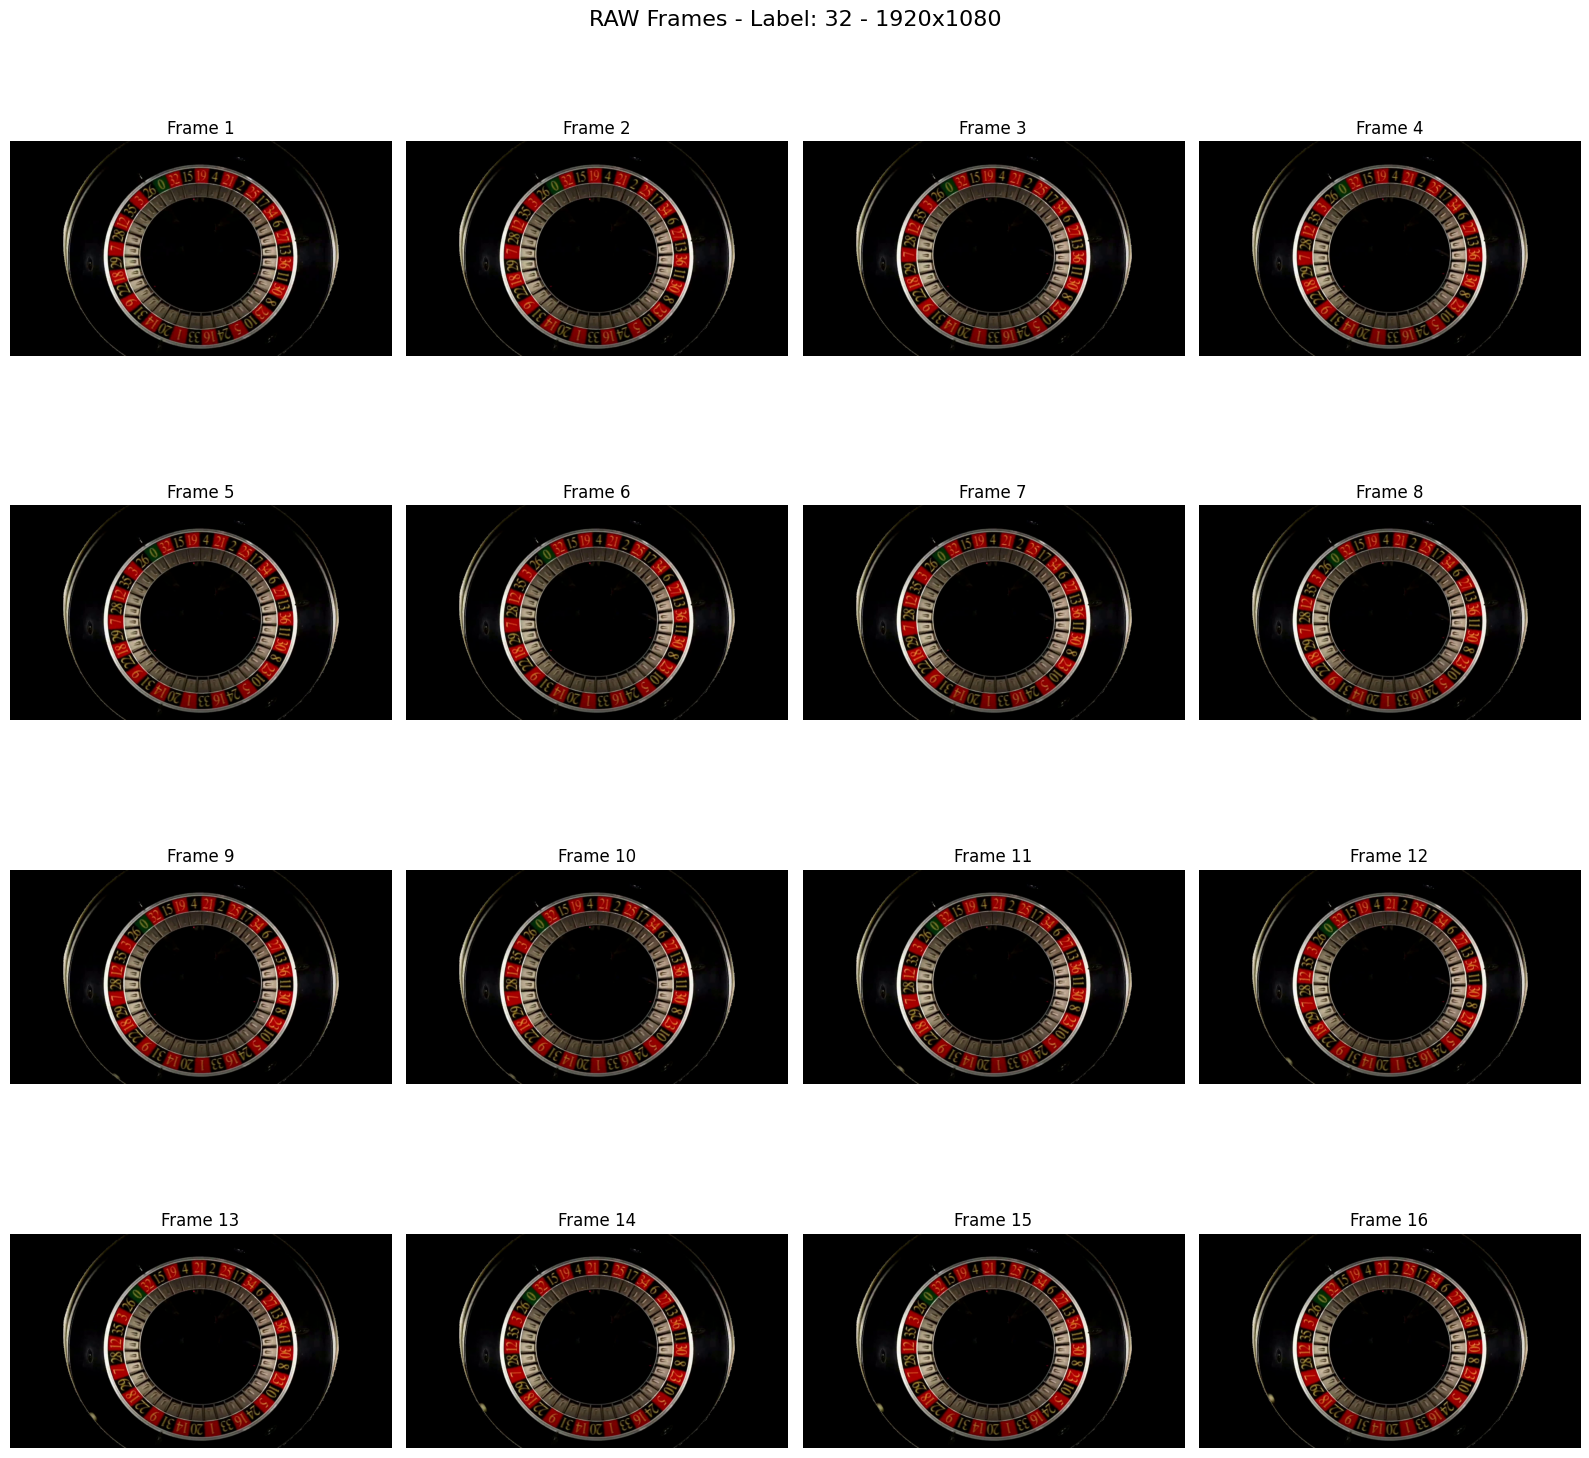

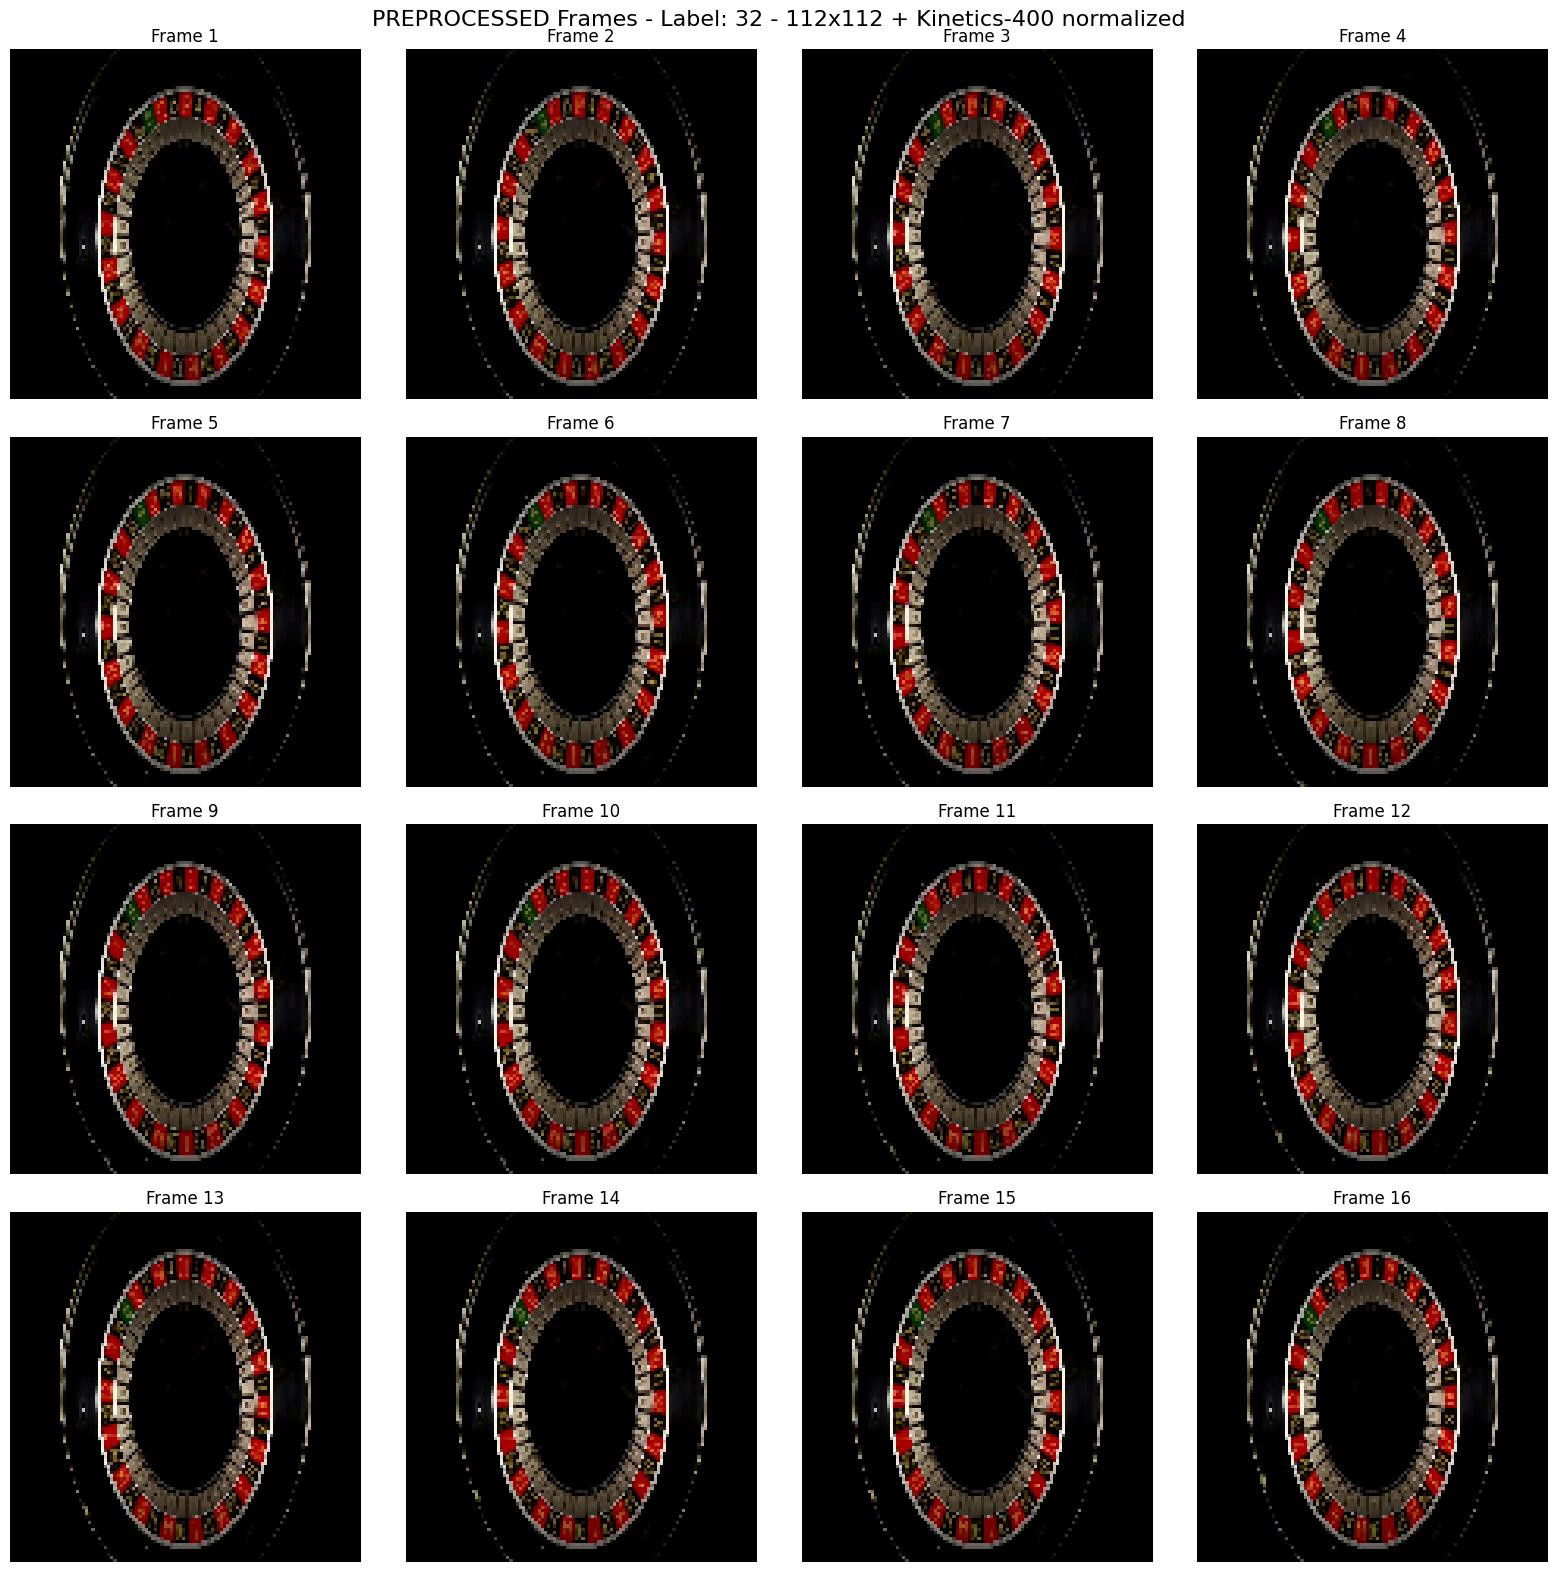


Displayed all 16 frames in two separate grids:
  1st grid: Raw frames from original video
  2nd grid: Preprocessed frames (resized + normalized, then denormalized for display)

Run this cell again to see a different random video


In [7]:
# Visualize all 16 frames
import random

def denormalize_frame(frame_tensor, mean, std):
    """Reverse the Kinetics-400 normalization for visualization"""
    # frame_tensor is (C, H, W)
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    denorm = frame_tensor * std + mean
    denorm = torch.clamp(denorm, 0, 1)  # Ensure valid range
    return denorm

def load_raw_frames(video_path, num_frames=16):
    """Load raw frames without preprocessing"""
    cap = cv2.VideoCapture(str(video_path))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    if total_frames < num_frames:
        indices = list(range(total_frames)) + [total_frames-1] * (num_frames - total_frames)
    else:
        indices = list(range(num_frames))
    
    frames = []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if ret:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame)
    
    cap.release()
    return frames

# Select 1 random video from dataset
random_idx = random.randint(0, len(dataset_no_aug) - 1)

mean = [0.43216, 0.394666, 0.37645]
std = [0.22803, 0.22145, 0.216989]

# Load the preprocessed video
video_frames, label = dataset_no_aug[random_idx]  # Shape: (C, T, H, W)
video_path = dataset_no_aug.df.iloc[random_idx]['input_path']
full_video_path = dataset_no_aug.dataset_root / video_path

# Load raw frames
raw_frames = load_raw_frames(full_video_path, num_frames=16)

print("Visualizing RAW and PREPROCESSED frames from 1 random video:")
print("=" * 80)
print(f"Video: {video_path}")
print(f"Label: {label}")
print(f"Preprocessed shape: {video_frames.shape}")
print(f"Raw frame shape: {raw_frames[0].shape}")
print("=" * 80)

# Raw frames grid
fig1, axes1 = plt.subplots(4, 4, figsize=(16, 16))
axes1 = axes1.flatten()

for frame_idx in range(16):
    raw_frame = raw_frames[frame_idx]
    axes1[frame_idx].imshow(raw_frame)
    axes1[frame_idx].axis('off')
    axes1[frame_idx].set_title(f'Frame {frame_idx + 1}', fontsize=12)

plt.suptitle(f'RAW Frames - Label: {label} - {raw_frames[0].shape[1]}x{raw_frames[0].shape[0]}', 
             fontsize=16)
plt.tight_layout()
plt.show()

# Preprocessed frames grid
fig2, axes2 = plt.subplots(4, 4, figsize=(16, 16))
axes2 = axes2.flatten()

for frame_idx in range(16):
    frame = video_frames[:, frame_idx, :, :]  # (C, H, W)
    frame_denorm = denormalize_frame(frame, mean, std)
    frame_np = frame_denorm.permute(1, 2, 0).numpy()
    
    axes2[frame_idx].imshow(frame_np)
    axes2[frame_idx].axis('off')
    axes2[frame_idx].set_title(f'Frame {frame_idx + 1}', fontsize=12)

plt.suptitle(f'PREPROCESSED Frames - Label: {label} - 112x112 + Kinetics-400 normalized', 
             fontsize=16)
plt.tight_layout()
plt.show()

print(f"\nDisplayed all 16 frames in two separate grids:")
print(f"  1st grid: Raw frames from original video")
print(f"  2nd grid: Preprocessed frames (resized + normalized, then denormalized for display)")
print(f"\nRun this cell again to see a different random video")

## 6. Training Loop

Main training loop - run this to train the model.

In [8]:
# Training function
def train_model(model, train_loader, val_loader, config, device):
    """Full training loop"""
    
    model = model.to(device)
    
    # Unfreeze last ResNet layer for fine-tuning
    print("\nUnfreezing ResNet layer4 for fine-tuning...")
    for param in model.model.layer4.parameters():
        param.requires_grad = True
    
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"   Trainable parameters: {trainable_params:,}")
    
    # Setup
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam([
        {'params': model.model.layer4.parameters(), 'lr': 1e-5},  # Lower LR for pre-trained layers
        {'params': model.model.fc.parameters(), 'lr': config['learning_rate']}
    ], weight_decay=1e-4)
    
    history = {
        'train_loss': [], 'train_acc': [], 'train_top5_acc': [],
        'val_loss': [], 'val_acc': [], 'val_top5_acc': []
    }
    
    print(f"\n{'='*60}")
    print(f"Starting training for {config['num_epochs']} epochs")
    print(f"{'='*60}\n")
    
    for epoch in range(config['num_epochs']):
        print(f"\nEpoch {epoch+1}/{config['num_epochs']}")
        print("-" * 60)
        
        train_loss, train_acc, train_top5_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        
        val_loss, val_acc, val_top5_acc, _, _, _ = test(model, val_loader, criterion, device)
        
        # Save history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['train_top5_acc'].append(train_top5_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_top5_acc'].append(val_top5_acc)
        
        # Print epoch summary
        print(f"\nEpoch {epoch+1} Summary:")
        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Train Top-5: {train_top5_acc:.2f}%")
        print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}% | Val Top-5:   {val_top5_acc:.2f}%")
        
        # Save model weights for this epoch
        epoch_save_path = config['save_path'].replace('.pth', f'_epoch_{epoch+1}.pth')
        torch.save(model.state_dict(), epoch_save_path)
        print(f"  Model saved: {epoch_save_path}")
    
    print(f"\n{'='*60}")
    print(f"Training completed!")
    print(f"All epoch models saved with pattern: {config['save_path'].replace('.pth', '_epoch_N.pth')}")
    print(f"{'='*60}\n")
    
    return history

history = train_model(model, train_loader, val_loader, CONFIG, device)


Unfreezing ResNet layer4 for fine-tuning...
   Trainable parameters: 25,049,637

Starting training for 10 epochs


Epoch 1/10
------------------------------------------------------------


Testing: 100%|██████████| 19/19 [00:51<00:00,  2.72s/it, loss=3.7, acc=4.83, top5=13.8] 



Epoch 1 Summary:
  Train Loss: 3.6775 | Train Acc: 2.38% | Train Top-5: 11.75%
  Val Loss:   3.6157 | Val Acc:   4.83% | Val Top-5:   13.79%
  Model saved: roulette_model_epoch_1.pth

Epoch 2/10
------------------------------------------------------------


Testing: 100%|██████████| 19/19 [00:56<00:00,  2.95s/it, loss=3.66, acc=2.07, top5=14.5]



Epoch 2 Summary:
  Train Loss: 3.6171 | Train Acc: 3.23% | Train Top-5: 14.75%
  Val Loss:   3.6206 | Val Acc:   2.07% | Val Top-5:   14.48%
  Model saved: roulette_model_epoch_2.pth

Epoch 3/10
------------------------------------------------------------


...


Epoch 8 Summary:
  Train Loss: 3.6073 | Train Acc: 3.38% | Train Top-5: 15.75%
  Val Loss:   3.6175 | Val Acc:   2.07% | Val Top-5:   10.34%
  Model saved: roulette_model_epoch_8.pth

Epoch 9/10
------------------------------------------------------------


Testing: 100%|██████████| 19/19 [00:50<00:00,  2.65s/it, loss=3.66, acc=3.45, top5=13.1]



Epoch 9 Summary:
  Train Loss: 3.6115 | Train Acc: 3.00% | Train Top-5: 13.98%
  Val Loss:   3.6053 | Val Acc:   3.45% | Val Top-5:   13.10%
  Model saved: roulette_model_epoch_9.pth

Epoch 10/10
------------------------------------------------------------


Testing: 100%|██████████| 19/19 [00:52<00:00,  2.75s/it, loss=3.67, acc=5.52, top5=14.5]


Epoch 10 Summary:
  Train Loss: 3.6057 | Train Acc: 3.92% | Train Top-5: 14.98%
  Val Loss:   3.6093 | Val Acc:   5.52% | Val Top-5:   14.48%
  Model saved: roulette_model_epoch_10.pth

Training completed!
All epoch models saved with pattern: roulette_model_epoch_N.pth



## 6.5. Save Training Results

Save history and data split for reproducibility.

In [10]:
import pickle
import json

# Save training history
with open('training_history.pkl', 'wb') as f:
    pickle.dump(history, f)
print("Training history saved to 'training_history.pkl'")

# JSON
with open('training_history.json', 'w') as f:
    json.dump(history, f, indent=2)
print("Training history saved to 'training_history.json'")

# Save train/test split indices
split_info = {
    'train_indices': train_dataset.indices,
    'test_indices': test_dataset.indices,
    'train_size': len(train_dataset),
    'test_size': len(test_dataset),
    'total_size': len(dataset_aug),
    'config': CONFIG
}

with open('train_test_split.pkl', 'wb') as f:
    pickle.dump(split_info, f)
print("Train/test split info saved to 'train_test_split.pkl'")

print(f"\nSaved:")
print(f"   - training_history.pkl / .json")
print(f"   - train_test_split.pkl")
print(f"   - {CONFIG['save_path']} (model weights)")


Training history saved to 'training_history.pkl'
Training history saved to 'training_history.json'
Train/test split info saved to 'train_test_split.pkl'

Saved:
   - training_history.pkl / .json
   - train_test_split.pkl
   - roulette_model.pth (model weights)


### Load saved history

To restore graphs:

Training history loaded
Test loader recreated with same split


C:\Users\jjzsi\AppData\Local\Temp\ipykernel_14048\682673727.py:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(split_info['config']['save_

Model weights loaded


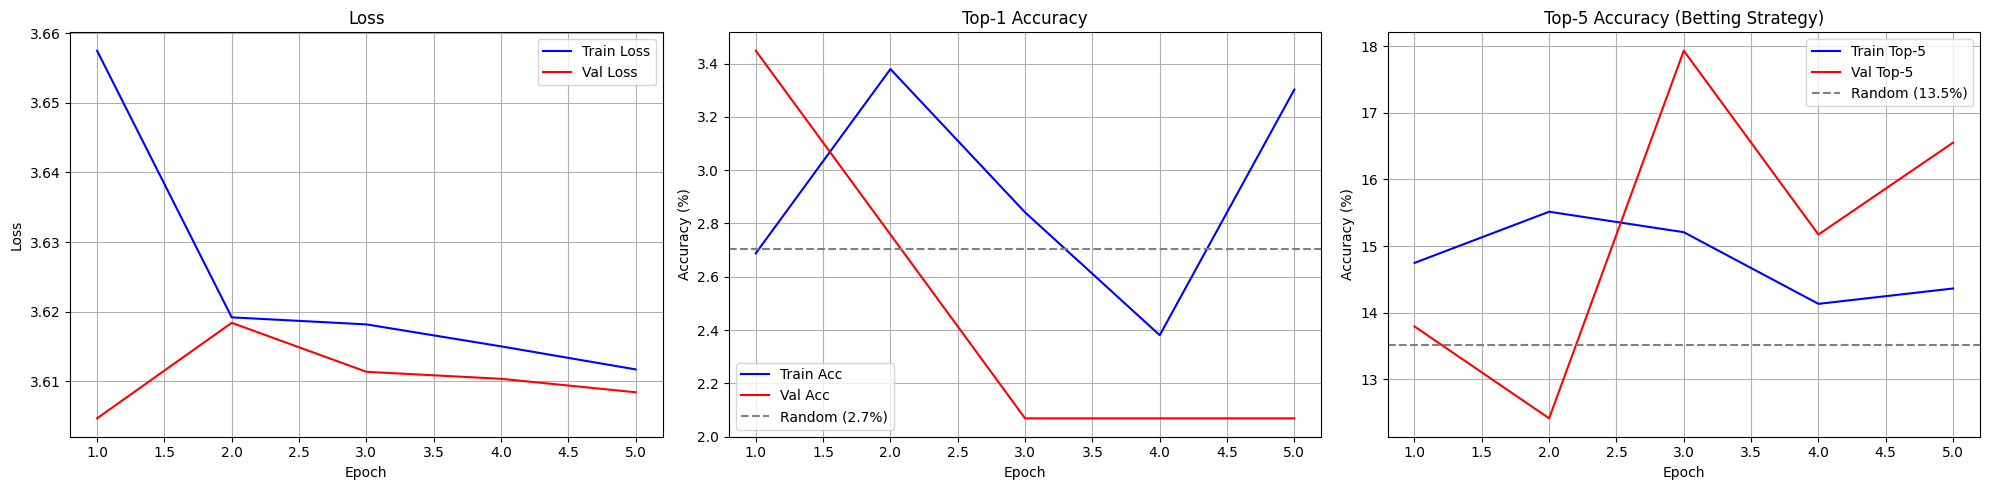

Testing: 100%|██████████| 32/32 [01:28<00:00,  2.77s/it, loss=3.58, acc=3.52, top5=13.7]
c:\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", 


Test Set Evaluation Results
Test Loss: 3.6065

1. TOP-1 BETTING (1 unit on most likely number):
  Accuracy: 3.52%
  Random Baseline: 2.70%
  Improvement: 1.30x over random
  Expected return: 1.27 units
  Expected profit: 0.27 units per spin

2. TOP-5 EQUAL BETTING (1 unit each on top 5):
  Top-5 Accuracy: 13.67%
  Random Baseline: 13.51%
  Improvement: 1.01x over random
  Cost per spin: 5 units
  Expected return: 4.92 units
  Expected profit: -0.08 units per spin
  Break-even accuracy: 13.89%

3. TOP-5 PROPORTIONAL BETTING (5 units split by probability):
  Cost per spin: 5 units
  Expected return: 4.92 units
  Expected profit: -0.08 units per spin
  Improvement over equal betting: inf%

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         5
           1       0.00      0.00      0.00         6
           2       0.00      0.00      0.00         7
           3       0.00      0.00      0.00         5
         

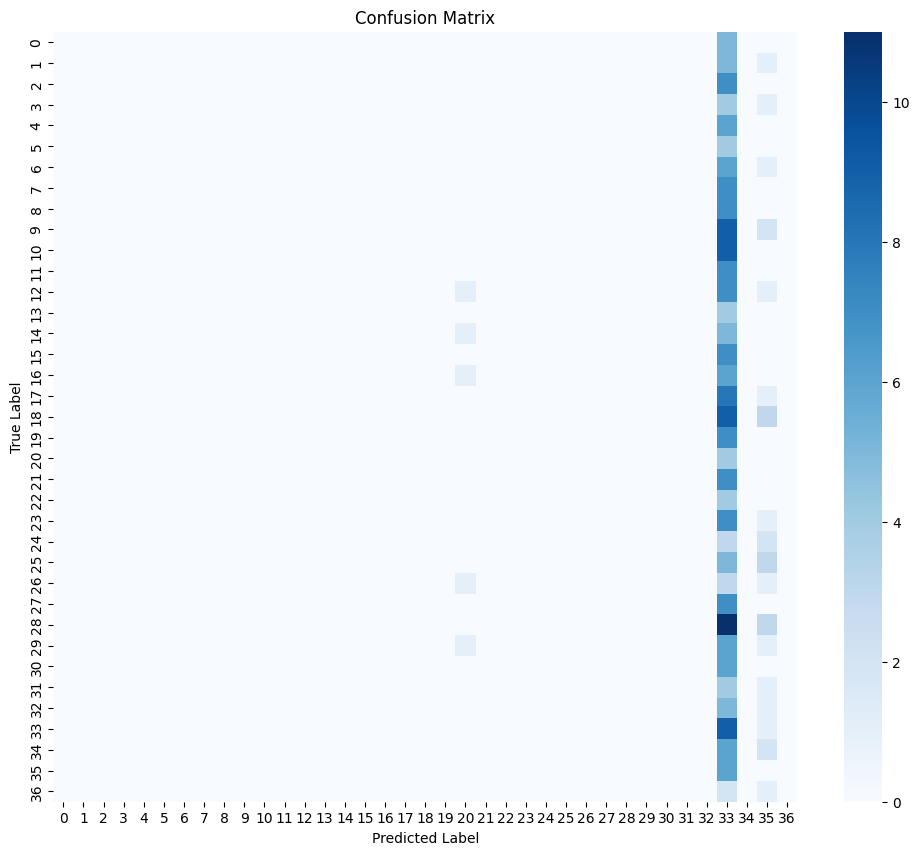

In [12]:
# Load training history
with open('training_history.pkl', 'rb') as f:
    history = pickle.load(f)
print("Training history loaded")

# Load split info and recreate test_loader
with open('train_test_split.pkl', 'rb') as f:
    split_info = pickle.load(f)

# Recreate dataset
dataset = RouletteVideoDataset(
    csv_path=split_info['config']['csv_path'],
    dataset_root=split_info['config']['dataset_root'],
    num_frames=split_info['config']['num_frames'],
    frame_size=split_info['config']['frame_size']
)

# Recreate same train/test split using saved indices
from torch.utils.data import Subset
train_dataset = Subset(dataset, split_info['train_indices'])
test_dataset = Subset(dataset, split_info['test_indices'])

test_loader = DataLoader(
    test_dataset,
    batch_size=split_info['config']['batch_size'],
    shuffle=False,
    num_workers=split_info['config']['num_workers'],
    pin_memory=True
)
print("Test loader recreated with same split")

# Load model weights
model = RoulettePredictor(num_classes=37, freeze_backbone=True)
model.load_state_dict(torch.load(split_info['config']['save_path']))
model = model.to(device)
print("Model weights loaded")

plot_training_history(history)
final_acc = evaluate_model(model, test_loader, device)

## 7. Visualization & Evaluation

Plot training curves and evaluate model performance.

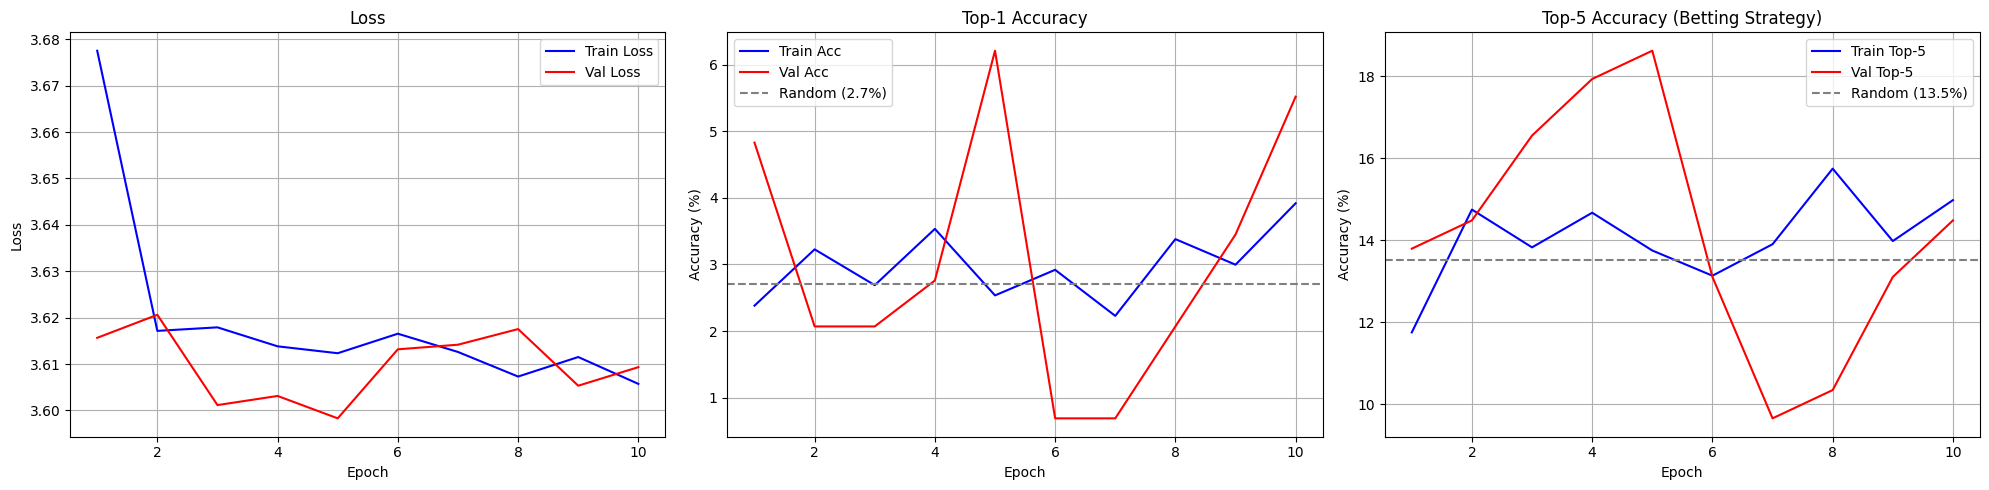

Testing: 100%|██████████| 32/32 [01:34<00:00,  2.94s/it, loss=3.62, acc=2.73, top5=12.5]
c:\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", 


Test Set Evaluation Results
Test Loss: 3.6125

1. TOP-1 BETTING (1 unit on most likely number):
  Accuracy: 2.73%
  Random Baseline: 2.70%
  Improvement: 1.01x over random
  Expected return: 0.98 units
  Expected profit: -0.02 units per spin

2. TOP-5 EQUAL BETTING (1 unit each on top 5):
  Top-5 Accuracy: 12.50%
  Random Baseline: 13.51%
  Improvement: 0.92x over random
  Cost per spin: 5 units
  Expected return: 4.50 units
  Expected profit: -0.50 units per spin
  Break-even accuracy: 13.89%

3. TOP-5 PROPORTIONAL BETTING (5 units split by probability):
  Cost per spin: 5 units
  Expected return: 4.50 units
  Expected profit: -0.50 units per spin
  Equal betting performs better

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         5
           1       0.00      0.00      0.00         6
           2       0.00      0.00      0.00         7
           3       0.00      0.00      0.00         5
           4   

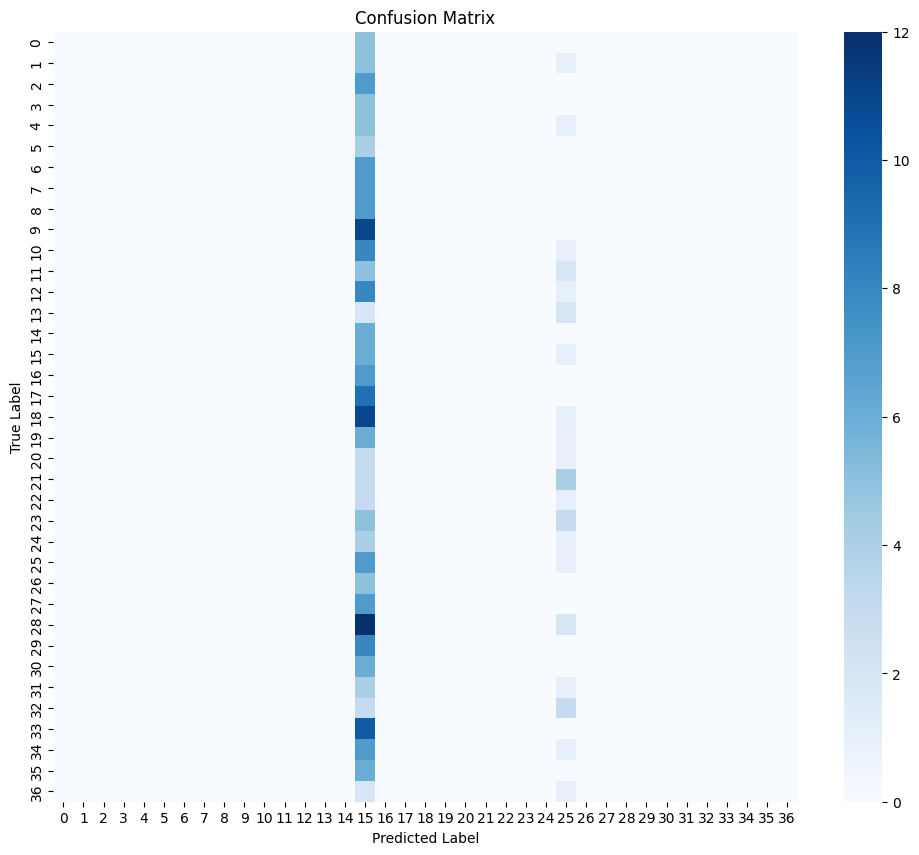

In [11]:
def plot_training_history(history):
    """Plot training and validation metrics"""
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 5))
    
    epochs = range(1, len(history['train_loss']) + 1)
    
    # Loss plot
    ax1.plot(epochs, history['train_loss'], 'b-', label='Train Loss')
    if 'val_loss' in history:
        ax1.plot(epochs, history['val_loss'], 'r-', label='Val Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Loss')
    ax1.legend()
    ax1.grid(True)
    
    # Top-1 Accuracy plot
    ax2.plot(epochs, history['train_acc'], 'b-', label='Train Acc')
    if 'val_acc' in history:
        ax2.plot(epochs, history['val_acc'], 'r-', label='Val Acc')
    ax2.axhline(y=100/37, color='gray', linestyle='--', label='Random (2.7%)')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_title('Top-1 Accuracy')
    ax2.legend()
    ax2.grid(True)
    
    # Top-5 Accuracy plot
    ax3.plot(epochs, history['train_top5_acc'], 'b-', label='Train Top-5')
    if 'val_top5_acc' in history:
        ax3.plot(epochs, history['val_top5_acc'], 'r-', label='Val Top-5')
    ax3.axhline(y=100*5/37, color='gray', linestyle='--', label='Random (13.5%)')
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('Accuracy (%)')
    ax3.set_title('Top-5 Accuracy (Betting Strategy)')
    ax3.legend()
    ax3.grid(True)
    
    plt.tight_layout()
    plt.show()

def evaluate_model(model, test_loader, device):
    """Detailed model evaluation on test set"""
    model.eval()
    criterion = nn.CrossEntropyLoss()
    
    test_loss, test_acc, test_top5_acc, all_preds, all_labels, all_probs = test(
        model, test_loader, criterion, device
    )
    
    # Calculate proportional betting metrics
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    
    total_bet_equal = 0
    total_winnings_equal = 0
    total_bet_prop = 0
    total_winnings_prop = 0
    
    for i in range(len(all_labels)):
        probs = all_probs[i]
        true_label = all_labels[i]
        
        # Get top-5 indices and probabilities
        top5_indices = np.argsort(probs)[-5:][::-1]
        top5_probs = probs[top5_indices]
        
        # Equal betting (1 unit each on top-5)
        total_bet_equal += 5
        if true_label in top5_indices:
            total_winnings_equal += 36  # Win 36 units (35:1 + original bet)
        
        # Proportional betting (5 units distributed by probability)
        prob_sum = top5_probs.sum()
        bets = (top5_probs / prob_sum) * 5  # Normalize to 5 units total
        total_bet_prop += 5
        
        if true_label in top5_indices:
            bet_amount = bets[np.where(top5_indices == true_label)[0][0]]
            total_winnings_prop += bet_amount * 36
    
    avg_return_equal = total_winnings_equal / len(all_labels)
    avg_profit_equal = avg_return_equal - 5
    avg_return_prop = total_winnings_prop / len(all_labels)
    avg_profit_prop = avg_return_prop - 5
    
    print(f"\n{'='*60}")
    print("Test Set Evaluation Results")
    print(f"{'='*60}")
    print(f"Test Loss: {test_loss:.4f}")
    print(f"\n1. TOP-1 BETTING (1 unit on most likely number):")
    print(f"  Accuracy: {test_acc:.2f}%")
    print(f"  Random Baseline: {100/37:.2f}%")
    print(f"  Improvement: {test_acc / (100/37):.2f}x over random")
    print(f"  Expected return: {test_acc/100 * 36:.2f} units")
    print(f"  Expected profit: {test_acc/100 * 36 - 1:.2f} units per spin")
    
    print(f"\n2. TOP-5 EQUAL BETTING (1 unit each on top 5):")
    print(f"  Top-5 Accuracy: {test_top5_acc:.2f}%")
    print(f"  Random Baseline: {100*5/37:.2f}%")
    print(f"  Improvement: {test_top5_acc / (100*5/37):.2f}x over random")
    print(f"  Cost per spin: 5 units")
    print(f"  Expected return: {avg_return_equal:.2f} units")
    print(f"  Expected profit: {avg_profit_equal:.2f} units per spin")
    print(f"  Break-even accuracy: {5/36*100:.2f}%")
    
    print(f"\n3. TOP-5 PROPORTIONAL BETTING (5 units split by probability):")
    print(f"  Cost per spin: 5 units")
    print(f"  Expected return: {avg_return_prop:.2f} units")
    print(f"  Expected profit: {avg_profit_prop:.2f} units per spin")
    if avg_profit_prop > avg_profit_equal:
        improvement = (avg_profit_prop / avg_profit_equal - 1) * 100 if avg_profit_equal > 0 else float('inf')
        print(f"  Improvement over equal betting: {improvement:.1f}%")
    else:
        print(f"  Equal betting performs better")
    
    # Classification report
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=[str(i) for i in range(37)]))
    
    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=False, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()
    
    return test_acc

plot_training_history(history)
final_acc = evaluate_model(model, test_loader, device)

## 8. Inference Function

Make predictions on new videos.

In [14]:
def predict_video(model, video_path, dataset_root, num_frames=16, frame_size=112, device='cuda'):
    """
    Predict roulette outcome for a single video
    
    Returns:
        predicted_number: Most likely number (0-36)
        probabilities: Probability distribution over all 37 numbers
    """
    model.eval()
    
    # Create temporary dataset for single video
    temp_df = pd.DataFrame([{
        'input_path': video_path,
        'label': 0  # Dummy label
    }])
    temp_csv = 'temp_inference.csv'
    temp_df.to_csv(temp_csv, index=False)
    
    dataset = RouletteVideoDataset(
        csv_path=temp_csv,
        dataset_root=dataset_root,
        num_frames=num_frames,
        frame_size=frame_size
    )
    
    video_tensor, _ = dataset[0]
    video_tensor = video_tensor.unsqueeze(0).to(device)  # Add batch dimension
    
    with torch.no_grad():
        outputs = model(video_tensor)
        probabilities = torch.softmax(outputs, dim=1)[0]
        predicted_number = torch.argmax(probabilities).item()
    
    # Clean up
    Path(temp_csv).unlink()
    
    return predicted_number, probabilities.cpu().numpy()

video_path = 'Input-Output Videos/SET 1/S1_INPUT_10.mp4'
pred_num, probs = predict_video(model, video_path, CONFIG['dataset_root'], device=device)
print(f"Predicted number: {pred_num}")
print(f"Confidence: {probs[pred_num]*100:.2f}%")

# Show top 5 predictions
top5_indices = np.argsort(probs)[-5:][::-1]
print("\nTop 5 predictions:")
for idx in top5_indices:
    print(f"  Number {idx}: {probs[idx]*100:.2f}%")

Predicted number: 15
Confidence: 2.98%

Top 5 predictions:
  Number 15: 2.98%
  Number 21: 2.87%
  Number 12: 2.85%
  Number 7: 2.82%
  Number 31: 2.81%
